# Simulated Annealing aplicado ao EVRP (GR17 adaptado)

### Modalidade: Busca Local — Disciplina de Inteligência Artificial (CESUPA)


## Seção 0 — Identificação

- **Equipe:** Gustavo Teixeira Bittencourt de Oliveira, Edgar Klewert, Christophe Abelem, Adler Castro
- **Disciplina:** Inteligência Artificial — CESUPA
- **Modalidade:** Busca Local
- **Problema escolhido:** EVRP (Electric Vehicle Routing Problem) — roteamento de veículos elétricos com restrição de autonomia de bateria e recarga em estações específicas, instanciado sobre o dataset **GR17** (TSPLIB) adaptado.


### Declaração de uso de Inteligência Artificial Generativa

- **Ferramenta utilizada:** Claude, via Claude Code (Anthropic).
- **Finalidade do uso:** apoio no desenvolvimento incremental do código (módulos de `src/busca_local/`), na formulação de testes automatizados (`tests/`), e na revisão crítica de decisões de modelagem e resultados experimentais (por exemplo, o diagnóstico da penalidade de viabilidade em degrau e a calibração analítica do `cooling_rate` do Simulated Annealing, discutidos nas Seções 3 e 5 deste notebook).
- **Extensão aproximada da contribuição:** [A PREENCHER PELA EQUIPE — descrever qual fração do código/análise foi gerada vs. revisada/decidida pela equipe]
- **Medidas adotadas para validação do conteúdo:**
  - suíte de testes automatizados (`pytest`, ver diretório `tests/`), cobrindo o carregamento do dataset, o mapeamento EVRP, a função objetivo, os operadores de vizinhança e os algoritmos de busca;
  - validação estatística dos resultados experimentais via **teste de Wilcoxon** pareado (Seção 7);
  - revisão manual, pela equipe, das decisões de modelagem (mapeamento de estações de recarga, parâmetros de bateria, estrutura da função objetivo), documentadas em `docs/DECISOES.md`.


## Seção 1 — Contextualização do problema

### O EVRP como problema de otimização

O **EVRP (Electric Vehicle Routing Problem)** é uma variante do clássico
problema de roteamento de veículos (VRP) em que os veículos da frota são
**elétricos** e, portanto, possuem autonomia de bateria limitada. Além de
minimizar a distância total percorrida (o objetivo clássico do VRP), a
solução precisa respeitar essa restrição de autonomia, o que normalmente
exige desviar a rota por **estações de recarga** ao longo do trajeto.

A motivação real é direta: empresas de logística e entrega que adotam
frotas elétricas (por custo operacional ou exigência regulatória/ambiental)
não podem simplesmente reaproveitar o planejamento de rotas feito para
veículos a combustão — uma rota "ótima" em distância pode ser **inviável**
na prática se exigir um trecho maior do que a bateria suporta sem recarga.
O problema de otimização, portanto, passa a ter duas dimensões
entrelaçadas: **custo de deslocamento** e **viabilidade energética**, o que
torna o espaço de busca mais irregular (rotas de baixo custo podem ser
inviáveis; rotas viáveis podem ter custo alto) — um cenário adequado para
algoritmos de Busca Local, que navegam esse espaço por meio de pequenas
modificações incrementais na solução corrente.

### Origem do dataset

Este módulo adota o **GR17 (TSPLIB, Groetschel)** — um TSP clássico de 17
cidades, com matriz de distância real e tour ótimo conhecido (custo
**2085**) — **adaptado** para EVRP por meio de um mapeamento manual de
papéis (depósito, estações de recarga, clientes) aos nós já existentes,
sem alterar nenhuma distância da matriz original.

Essa adaptação foi feita após avaliar e descartar datasets EVRP prontos,
por não se encaixarem no escopo e prazo do módulo:

- **Schneider, Stenger & Goeke (2014)**, *"The Electric Vehicle-Routing
  Problem with Time Windows and Recharging Stations"* (Transportation
  Science 48(4)). O dataset E-VRPTW derivado desse trabalho inclui janelas
  de tempo por cliente, o que adiciona uma dimensão de complexidade
  (restrições temporais combinadas com restrições de bateria) além do que
  o módulo precisa demonstrar.
- **EC-TSP dataset (Mendeley)**, de Gialos & Zeimpekis (2023). Distribuído
  em formato Excel com múltiplas dimensões de dados (coordenadas, consumo,
  tempos, etc.), o que exigiria um trabalho de *parsing* e limpeza
  desproporcional ao tempo disponível para o módulo.

Com autorização explícita da professora para adaptar um dataset existente
(desde que documentado), adotamos o GR17. As estações de recarga (nós 3, 9
e 14) foram posicionadas de modo a se distribuir ao longo do tour ótimo de
referência, evitando concentração das estações em um só trecho do
percurso — a justificativa completa, incluindo os parâmetros do modelo de
bateria (`BATTERY_CAPACITY=800`, `CONSUMPTION_RATE=1.0`,
`RECHARGE_MODE="full"`), está documentada em `docs/DECISOES.md`.

A tabela e a matriz de distância abaixo são carregadas diretamente dos
arquivos de dados (`data/raw/gr17_d.txt`, `data/raw/gr17_s.txt`) — nenhum
valor foi digitado manualmente.


In [1]:
import sys
import random
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

from busca_local.dataset import load_distance_matrix, load_optimal_tour
from busca_local.evrp_mapping import (
    DEPOT,
    CHARGING_STATIONS,
    CUSTOMERS,
    BATTERY_CAPACITY,
    CONSUMPTION_RATE,
    RECHARGE_MODE,
    is_feasible_route,
)
from busca_local.problem import evaluate, route_cost, route_penalty, random_valid_route
from busca_local.neighborhood import get_neighbor
from busca_local.hill_climbing import hill_climbing, hill_climbing_fixed_budget, HillClimbingResult
from busca_local.simulated_annealing import simulated_annealing, DEFAULT_INITIAL_TEMPERATURE
from busca_local.simulated_annealing_reheating import simulated_annealing_with_reheating
from busca_local.sa_utils import compute_cooling_rate
from busca_local.experiments import run_multiple_hill_climbing

DATA_DIR = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "resultados"
distance_matrix = load_distance_matrix(DATA_DIR / "gr17_d.txt")
optimal_tour = load_optimal_tour(DATA_DIR / "gr17_s.txt")

print(f"Matriz de distância: {distance_matrix.shape[0]}x{distance_matrix.shape[1]} nós")
print(f"Tour ótimo de referência (1-indexado): {optimal_tour.one_indexed}")
print(f"Custo do tour ótimo: {route_cost(optimal_tour.one_indexed + [DEPOT], distance_matrix):.0f}")


Matriz de distância: 17x17 nós
Tour ótimo de referência (1-indexado): [1, 4, 13, 7, 8, 6, 17, 14, 15, 3, 11, 10, 2, 5, 9, 12, 16]
Custo do tour ótimo: 2085


In [2]:
def node_role(node):
    if node == DEPOT:
        return "Depósito"
    if node in CHARGING_STATIONS:
        return "Estação de recarga"
    return "Cliente"

mapping_df = pd.DataFrame({
    "nó (1-indexado)": list(range(1, 18)),
    "papel": [node_role(n) for n in range(1, 18)],
})
mapping_df


,nó (1-indexado),papel
0,1,Depósito
1,2,Cliente
2,3,Estação de recarga
3,4,Cliente
4,5,Cliente
5,6,Cliente
6,7,Cliente
7,8,Cliente
8,9,Estação de recarga
9,10,Cliente


In [3]:
distance_df = pd.DataFrame(
    distance_matrix,
    index=[f"{i}" for i in range(1, 18)],
    columns=[f"{i}" for i in range(1, 18)],
)
distance_df


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
1,0,633,257,91,412,150,80,134,259,505,353,324,70,211,268,246,121
2,633,0,390,661,227,488,572,530,555,289,282,638,567,466,420,745,518
3,257,390,0,228,169,112,196,154,372,262,110,437,191,74,53,472,142
4,91,661,228,0,383,120,77,105,175,476,324,240,27,182,239,237,84
5,412,227,169,383,0,267,351,309,338,196,61,421,346,243,199,528,297
6,150,488,112,120,267,0,63,34,264,360,208,329,83,105,123,364,35
7,80,572,196,77,351,63,0,29,232,444,292,297,47,150,207,332,29
8,134,530,154,105,309,34,29,0,249,402,250,314,68,108,165,349,36
9,259,555,372,175,338,264,232,249,0,495,352,95,189,326,383,202,236
10,505,289,262,476,196,360,444,402,495,0,154,578,439,336,240,685,390


Parâmetros do modelo de bateria adotados (ver `busca_local.evrp_mapping`):


In [4]:
battery_params_df = pd.DataFrame({
    "parâmetro": ["BATTERY_CAPACITY", "CONSUMPTION_RATE", "RECHARGE_MODE"],
    "valor": [BATTERY_CAPACITY, CONSUMPTION_RATE, RECHARGE_MODE],
})
battery_params_df


,parâmetro,valor
0,BATTERY_CAPACITY,800
1,CONSUMPTION_RATE,1.0
2,RECHARGE_MODE,full


## Seção 2 — Justificativa dos algoritmos

### Por que Busca Local se aplica ao EVRP

O espaço de soluções do EVRP (permutações dos clientes, intercaladas
opcionalmente com estações de recarga) cresce combinatorialmente com o
número de nós, sem estrutura que permita uma solução analítica direta —
é um problema **NP-difícil** por herdar a dificuldade combinatória do TSP,
agravada pela dimensão adicional de viabilidade de bateria. Não há uma
forma fechada para "a melhor rota"; o que existe é uma função objetivo
computável para qualquer rota candidata (`problem.evaluate`) e um conjunto
de pequenas modificações que transformam uma rota em outra "vizinha"
(`neighborhood.get_neighbor`). Essa é exatamente a estrutura que a **Busca
Local** explora: partir de uma solução candidata e melhorá-la
iterativamente por meio de movimentos locais, sem precisar enumerar o
espaço de busca inteiro (inviável para instâncias maiores) nem depender de
gradientes analíticos (inexistentes aqui, já que o espaço é discreto).

Além disso, a interação entre custo de distância e penalidade de bateria
(Seção 3) cria um espaço de busca **irregular**, com múltiplos mínimos
locais e platôs — um cenário em que a escolha da regra de aceitação de
vizinhos (estrita, como no Hill Climbing; ou probabilística, como no
Simulated Annealing) tem impacto direto e observável na qualidade da
solução final, o que torna o EVRP adaptado do GR17 um bom problema para
demonstrar as diferenças entre os algoritmos exigidos pela modalidade.

### Por que os três algoritmos escolhidos

- **Hill Climbing com reinício aleatório** (obrigatório, baseline): serve
  como referência de comparação — um algoritmo guloso, que só aceita
  vizinhos melhores-ou-iguais, e por isso fica preso no primeiro mínimo
  local (ou platô) que encontrar. O reinício aleatório é a forma mais
  simples de mitigar essa limitação, tentando múltiplos pontos de partida
  independentes. É o algoritmo mais direto de implementar e entender, e
  estabelece a "linha de base" contra a qual os demais algoritmos são
  avaliados.
- **Simulated Annealing** (algoritmo principal da modalidade): resolve
  justamente a limitação do Hill Climbing ao aceitar, com probabilidade
  decrescente ao longo do tempo (controlada pela temperatura), vizinhos
  **piores** que a solução corrente. Isso permite escapar de mínimos
  locais e platôs que prenderiam uma busca puramente gulosa — um
  comportamento particularmente relevante no EVRP adaptado, em que (como
  discutido na Seção 3) escapar da região inviável do espaço de busca pode
  exigir aceitar temporariamente um aumento de custo antes de encontrar uma
  rota viável de custo menor.
- **Variante aprimorada — Simulated Annealing com reaquecimento** (Seção
  6): estende o SA com um mecanismo de reaquecimento da temperatura ao
  detectar estagnação prolongada da busca, buscando reabrir a exploração
  probabilística depois que o resfriamento geométrico já reduziu a
  temperatura a um patamar muito baixo para o resto da execução —
  situação diagnosticada empiricamente durante a calibração do SA
  (Seção 5) e que motiva diretamente essa variante. Como a Seção 6/7
  discutem, essa variante recupera boa parte do comportamento do SA puro
  mas não o supera nesta instância — um resultado negativo também
  reportado, não só o resultado esperado.


## Seção 3 — Definição formal do problema

**Estado.** Uma solução candidata é uma **rota**: uma sequência de nós que
começa e termina no depósito, visita cada cliente exatamente uma vez, e
pode conter zero ou mais visitas a estações de recarga (repetíveis) em
qualquer posição intermediária. Sintaticamente, qualquer sequência que
respeite essa estrutura é um estado válido — a viabilidade de bateria é
tratada pela função objetivo, não pela definição do estado (ver
`problem.random_valid_route`).

**Vizinhança.** Três operações, aplicadas cada uma sobre uma cópia da rota
corrente (nunca modificam a rota original), compõem a função de vizinhança
usada por todos os algoritmos (`neighborhood.get_neighbor`, que escolhe
uma delas uniformemente a cada chamada):

- `swap_neighbor` — troca de posição dois nós não-depósito escolhidos
  aleatoriamente;
- `insert_station_neighbor` — insere uma estação de recarga aleatória em
  uma posição interna aleatória da rota;
- `remove_station_neighbor` — remove uma ocorrência de estação de recarga
  presente na rota, se houver alguma.

As duas últimas operações formam um par complementar que permite à busca
tanto **corrigir** viabilidade (inserindo estações) quanto **simplificar**
uma rota com estações redundantes (removendo-as) — sem essas duas
operações, uma rota sem estações jamais poderia se tornar viável, e vice-
versa.

**Função objetivo.** `problem.evaluate(rota) = custo de distância +
penalidade de viabilidade`, onde o custo de distância é a soma das
distâncias entre nós consecutivos (`route_cost`) e a penalidade
(`route_penalty`) é **zero** se a rota for totalmente viável de bateria, ou
`INFEASIBLE_PENALTY_BASE (1000) + déficit total de bateria` caso contrário.
Essa é a **única** função objetivo usada pelos três algoritmos da
modalidade — nenhum deles reimplementa seu próprio cálculo de custo,
condição necessária para que a comparação entre eles seja válida.

### A evolução da penalidade: de degrau para déficit acumulado

A formulação da penalidade não é a versão implementada originalmente.
Na primeira versão (documentada em `docs/DECISOES.md`), uma rota inviável
recebia uma penalidade em **degrau**: um valor fixo (`INFEASIBLE_PENALTY =
1_000_000`) somado apenas ao índice do trecho quebrado — ou seja, **toda**
rota inviável custava aproximadamente o mesmo, independentemente de estar
"quase viável" (faltando pouca energia para completar um trecho) ou "muito
inviável" (faltando muita). Sem gradiente entre essas duas situações, o
Hill Climbing — que só aceita vizinhos melhores-ou-iguais — não conseguia
progredir: tornar uma rota viável normalmente exige inserir **duas**
estações ao redor do mesmo cliente em sequência, e cada inserção isolada
aumentava o custo de distância sem que a penalidade em degrau desse
qualquer sinal de progresso. Em testes com até 200 reinícios × 5000
iterações (mais de 1 milhão de avaliações), **0 execuções** encontraram
uma solução viável.

A correção substituiu essa penalidade em degrau por uma **proporcional ao
déficit total de bateria acumulado** ao longo de toda a rota
(`evrp_mapping.compute_total_battery_deficit`), dando à busca um gradiente
real a seguir. O resultado foi imediato: nas mesmas condições de teste, o
Hill Climbing passou de 0/20 para **20/20 execuções viáveis**.

O código-fonte da versão em degrau não foi preservado no repositório (é um
histórico documentado em `docs/DECISOES.md`, não um módulo versionado), o
que impede reconstruir um gráfico comparativo direto entre as duas
implementações. A célula abaixo ilustra, em vez disso, o comportamento
**atual** (baseado em déficit) sobre uma sequência real de rotas com
viabilidade crescente: o valor de `INFEASIBLE_PENALTY = 1_000_000` citado
acima está documentado (não inventado) e é usado apenas como referência
textual de contraste — a versão em degrau atribuiria esse mesmo valor
(aproximadamente) às quatro primeiras linhas da tabela abaixo, apesar do
déficit real variar por um fator superior a 1,6× entre elas (déficit
máximo / déficit mínimo dentre as rotas inviáveis da tabela).

**Critério de parada.** Cada algoritmo usa um critério próprio, adequado à
sua natureza (detalhado nas Seções 4 e 5): o Hill Climbing para por
**estagnação** (um número máximo de iterações consecutivas sem melhora
estrita do custo, por reinício); o Simulated Annealing para por
**orçamento fixo de iterações**, já que seu resfriamento geométrico é
calibrado (Seção 5) para consumir a temperatura disponível exatamente ao
longo desse orçamento.


In [5]:
# Rotas com o MESMO conjunto e ordem de clientes, variando apenas o número
# de estações de recarga inseridas — ilustra o gradiente real de déficit
# de bateria que a penalidade atual introduz na função objetivo.
sample_routes = {
    "0 estações": [DEPOT] + CUSTOMERS + [DEPOT],
    "1 estação": [DEPOT] + CUSTOMERS[:7] + [3] + CUSTOMERS[7:] + [DEPOT],
    "2 estações": [DEPOT] + CUSTOMERS[:5] + [3] + CUSTOMERS[5:9] + [9] + CUSTOMERS[9:] + [DEPOT],
    "3 estações": [DEPOT] + CUSTOMERS[:4] + [3] + CUSTOMERS[4:7] + [9] + CUSTOMERS[7:10] + [14] + CUSTOMERS[10:] + [DEPOT],
}

# Uma rota totalmente viável, para contraste (busca simples até encontrar uma)
_rng_illustration = random.Random(7)
feasible_route = None
for _ in range(5000):
    candidate = random_valid_route(CUSTOMERS, CHARGING_STATIONS, DEPOT, _rng_illustration, station_insertion_probability=0.5)
    if is_feasible_route(candidate, distance_matrix, BATTERY_CAPACITY) is True:
        feasible_route = candidate
        break
sample_routes["rota viável (referência)"] = feasible_route

gradient_rows = []
for label, route in sample_routes.items():
    n_stations = sum(1 for node in route if node in CHARGING_STATIONS)
    penalty = route_penalty(route, distance_matrix, BATTERY_CAPACITY)
    deficit = max(0.0, penalty - 1000) if penalty > 0 else 0.0
    gradient_rows.append({
        "rota": label,
        "nº estações": n_stations,
        "custo de distância": route_cost(route, distance_matrix),
        "déficit de bateria": deficit,
        "penalidade atual (déficit)": penalty,
    })

gradient_df = pd.DataFrame(gradient_rows)
gradient_df


,rota,nº estações,custo de distância,déficit de bateria,penalidade atual (déficit)
0,0 estações,0,4423.0,3623.0,4623.0
1,1 estação,1,4641.0,3041.0,4041.0
2,2 estações,2,4774.0,2374.0,3374.0
3,3 estações,3,5361.0,2161.0,3161.0
4,rota viável (referência),9,4833.0,0.0,0.0


## Seção 4 — Hill Climbing com reinício aleatório

Execução única, com os parâmetros abaixo (`max_iterations_per_restart=2000`
iterações de estagnação tolerada por reinício, `n_restarts=20`, seed fixa
para reprodutibilidade). O gráfico mostra a evolução do custo da solução
corrente ao longo de todas as iterações realizadas, com uma linha vertical
tracejada marcando o início de cada novo reinício.


Melhor custo encontrado: 2484.0
Rota é viável: True
Total de avaliações (todos os reinícios): 77258
Custo final por reinício: [3136.0, 2632.0, 2801.0, 2679.0, 2790.0, 2508.0, 2486.0, 2910.0, 2530.0, 2898.0, 2694.0, 2484.0, 2534.0, 2934.0, 2936.0, 2826.0, 2864.0, 2937.0, 2620.0, 2954.0]


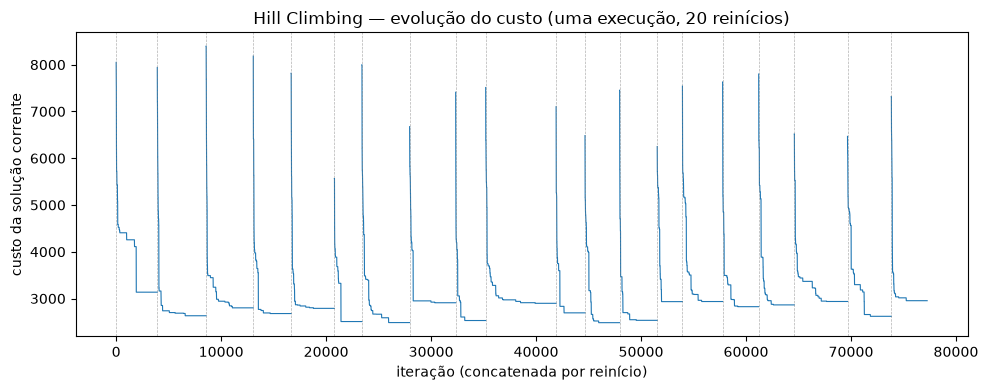

In [6]:
HC_MAX_ITERATIONS_PER_RESTART = 2000
HC_N_RESTARTS = 20
HC_SEED = 2026

hc_single_result = hill_climbing(
    distance_matrix=distance_matrix,
    customers=CUSTOMERS,
    charging_stations=CHARGING_STATIONS,
    depot=DEPOT,
    battery_capacity=BATTERY_CAPACITY,
    max_iterations_per_restart=HC_MAX_ITERATIONS_PER_RESTART,
    n_restarts=HC_N_RESTARTS,
    rng=random.Random(HC_SEED),
)

print(f"Melhor custo encontrado: {hc_single_result.best_cost:.1f}")
print(f"Rota é viável: {is_feasible_route(hc_single_result.best_route, distance_matrix, BATTERY_CAPACITY) is True}")
print(f"Total de avaliações (todos os reinícios): {hc_single_result.total_iterations}")
print(f"Custo final por reinício: {[round(c, 1) for c in hc_single_result.restart_costs]}")

fig, ax = plt.subplots(figsize=(10, 4))
offset = 0
for restart_history in hc_single_result.cost_history:
    xs = range(offset, offset + len(restart_history))
    ax.plot(xs, restart_history, color="tab:blue", linewidth=0.8)
    ax.axvline(offset, color="gray", linestyle="--", linewidth=0.5, alpha=0.6)
    offset += len(restart_history)
ax.set_xlabel("iteração (concatenada por reinício)")
ax.set_ylabel("custo da solução corrente")
ax.set_title("Hill Climbing — evolução do custo (uma execução, 20 reinícios)")
plt.tight_layout()
plt.show()


Em seguida, `run_multiple_hill_climbing` executa o mesmo algoritmo 30
vezes (seeds independentes derivadas de `seed_base=2026`), permitindo
observar a variabilidade da solução final em função apenas do estado
inicial (já que os demais parâmetros são idênticos entre execuções).


In [7]:
N_RUNS = 30
hc_multiple_results = run_multiple_hill_climbing(
    n_runs=N_RUNS,
    seed_base=HC_SEED,
    distance_matrix=distance_matrix,
    customers=CUSTOMERS,
    charging_stations=CHARGING_STATIONS,
    depot=DEPOT,
    battery_capacity=BATTERY_CAPACITY,
    max_iterations_per_restart=HC_MAX_ITERATIONS_PER_RESTART,
    n_restarts=HC_N_RESTARTS,
)

hc_costs = [r.best_cost for r in hc_multiple_results]
hc_feasible_flags = [
    is_feasible_route(r.best_route, distance_matrix, BATTERY_CAPACITY) is True
    for r in hc_multiple_results
]

hc_summary_df = pd.DataFrame([{
    "n execuções": N_RUNS,
    "melhor custo": min(hc_costs),
    "pior custo": max(hc_costs),
    "custo médio": float(np.mean(hc_costs)),
    "desvio padrão": float(np.std(hc_costs)),
    "taxa de viabilidade": f"{sum(hc_feasible_flags)}/{N_RUNS}",
}])
hc_summary_df


,n execuções,melhor custo,pior custo,custo médio,desvio padrão,taxa de viabilidade
0,30,2450.0,2554.0,2482.0,26.899814,30/30


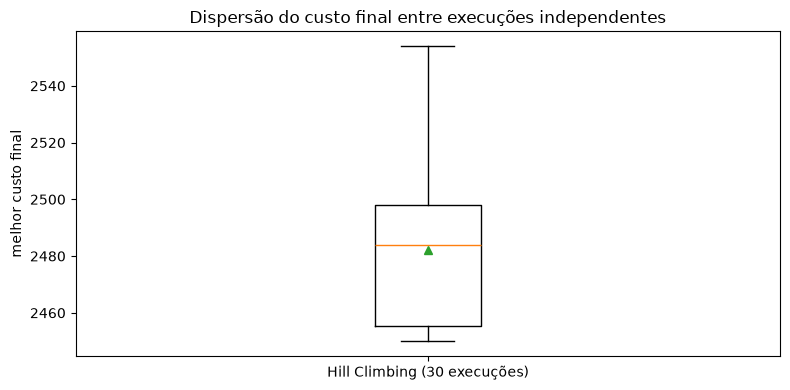

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(hc_costs, orientation="vertical", showmeans=True)
ax.set_ylabel("melhor custo final")
ax.set_xticklabels([f"Hill Climbing ({N_RUNS} execuções)"])
ax.set_title("Dispersão do custo final entre execuções independentes")
plt.tight_layout()
plt.show()


### Discussão — dependência do estado inicial, mínimos locais e platôs

Os resultados acima ilustram três pontos discutidos ao longo do
desenvolvimento deste módulo:

1. **Dependência do estado inicial.** Mesmo com 20 reinícios por execução,
   o custo final varia entre as 30 execuções independentes (ver desvio
   padrão na tabela acima) — cada reinício parte de uma rota inicial
   aleatória diferente (`random_valid_route`), e o Hill Climbing, por só
   aceitar vizinhos melhores-ou-iguais, converge para o mínimo local mais
   próximo dessa partida, não necessariamente o mínimo global. O reinício
   aleatório mitiga esse efeito (a melhor solução é sempre reportada entre
   os 20 reinícios), mas não o elimina — por isso a variância residual
   observada entre as 30 execuções completas.
2. **Mínimos locais e o episódio da penalidade em degrau.** O achado mais
   marcante desse efeito, já discutido na Seção 3, foi observado durante o
   desenvolvimento: com a penalidade de viabilidade antiga (em degrau), o
   Hill Climbing ficava preso permanentemente na região inviável do espaço
   de busca — 0 em 20 execuções encontravam uma rota viável, mesmo com
   mais de 1 milhão de avaliações no total. O problema não era o algoritmo
   em si, mas a ausência de gradiente na função objetivo: um "vale" de
   custo (inserir uma estação sem ainda ganhar viabilidade) que a regra de
   aceitação estrita do HC nunca atravessava. Após a correção da
   penalidade (déficit acumulado), esse mesmo algoritmo passou a encontrar
   solução viável em 20 de 20 execuções nas mesmas condições — evidência
   direta de que a formulação da função objetivo importa tanto quanto o
   algoritmo de busca escolhido.
3. **Platôs.** O critério de aceitação do Hill Climbing usado aqui aceita
   vizinhos de custo **igual** ao corrente (não apenas estritamente
   melhores), o que permite à busca "caminhar" por platôs de custo
   constante em vez de travar neles — o contador de estagnação, no
   entanto, conta esses passos de empate como iterações sem melhora
   (apenas melhora estrita zera o contador), então um platô longo ainda
   consome o orçamento de iterações do reinício e pode levá-lo a encerrar
   sem sair da região.


## Seção 5 — Simulated Annealing

O Simulated Annealing usa **resfriamento geométrico**:
`T(n) = T0 * cooling_rate ** n`, onde `T0` é a temperatura inicial e `n` é
o número da iteração. Quanto maior a temperatura, maior a probabilidade de
aceitar um vizinho pior (`exp(-delta / T)`); à medida que `T` cai, a busca
se torna progressivamente mais gulosa.

### Por que a calibração analítica do `cooling_rate` foi necessária

O valor de `cooling_rate` usado inicialmente (`0.995`, exploratório, ver
`simulated_annealing.DEFAULT_COOLING_RATE`) não foi escolhido em função do
orçamento de iterações da execução oficial. Um diagnóstico posterior (ver
`scratch_cooling_diagnosis.py` e célula de código abaixo) revelou que, com
esse valor fixo e `initial_temperature=5000`, a temperatura já cruza
abaixo de `1.0` muito antes do fim do orçamento de 20.000 iterações — a
partir daí, a probabilidade de aceitar um vizinho pior fica desprezível
para deltas de custo típicos do problema (dezenas a centenas), e o SA
passa a se comportar como uma busca gulosa comum pelo resto da execução,
desperdiçando a maior parte do orçamento sem explorar probabilisticamente.

A correção (`sa_utils.compute_cooling_rate`) deriva `cooling_rate`
analiticamente a partir de três parâmetros — `initial_temperature`,
`min_temperature` (temperatura-alvo ao final do orçamento) e
`max_iterations` — resolvendo `T0 * cooling_rate ** max_iterations =
min_temperature` para `cooling_rate`:

```
cooling_rate = (min_temperature / initial_temperature) ** (1 / max_iterations)
```

Isso garante que o resfriamento consuma o orçamento de iterações inteiro,
em vez de esvaziar-se prematuramente.


In [9]:
INITIAL_TEMPERATURE = DEFAULT_INITIAL_TEMPERATURE  # 5000.0
MIN_TEMPERATURE = 1.0
SA_MAX_ITERATIONS = 20_000
OLD_COOLING_RATE = 0.995

NEW_COOLING_RATE = compute_cooling_rate(INITIAL_TEMPERATURE, MIN_TEMPERATURE, SA_MAX_ITERATIONS)


def iteration_where_temperature_crosses_below(cooling_rate, threshold, max_iterations):
    for iteration in range(0, max_iterations + 1):
        if INITIAL_TEMPERATURE * (cooling_rate ** iteration) < threshold:
            return iteration
    return None


cross_old = iteration_where_temperature_crosses_below(OLD_COOLING_RATE, MIN_TEMPERATURE, SA_MAX_ITERATIONS)

print(f"cooling_rate antigo (fixo)    = {OLD_COOLING_RATE}")
print(f"cooling_rate novo (calibrado) = {NEW_COOLING_RATE:.10f}")
print()
print(f"Schedule antigo: T cruza abaixo de {MIN_TEMPERATURE} na iteração {cross_old} "
      f"({cross_old / SA_MAX_ITERATIONS:.2%} do orçamento de {SA_MAX_ITERATIONS})")
print(f"Schedule novo:   por construção, T atinge {MIN_TEMPERATURE} exatamente na última iteração "
      f"({SA_MAX_ITERATIONS}/{SA_MAX_ITERATIONS} = 100.00% do orçamento)")


cooling_rate antigo (fixo)    = 0.995
cooling_rate novo (calibrado) = 0.9995742310

Schedule antigo: T cruza abaixo de 1.0 na iteração 1700 (8.50% do orçamento de 20000)
Schedule novo:   por construção, T atinge 1.0 exatamente na última iteração (20000/20000 = 100.00% do orçamento)


Melhor custo encontrado: 2582.0
Rota é viável: True
Primeira iteração viável: 1355
Pioras aceitas após a primeira viabilidade: 2009


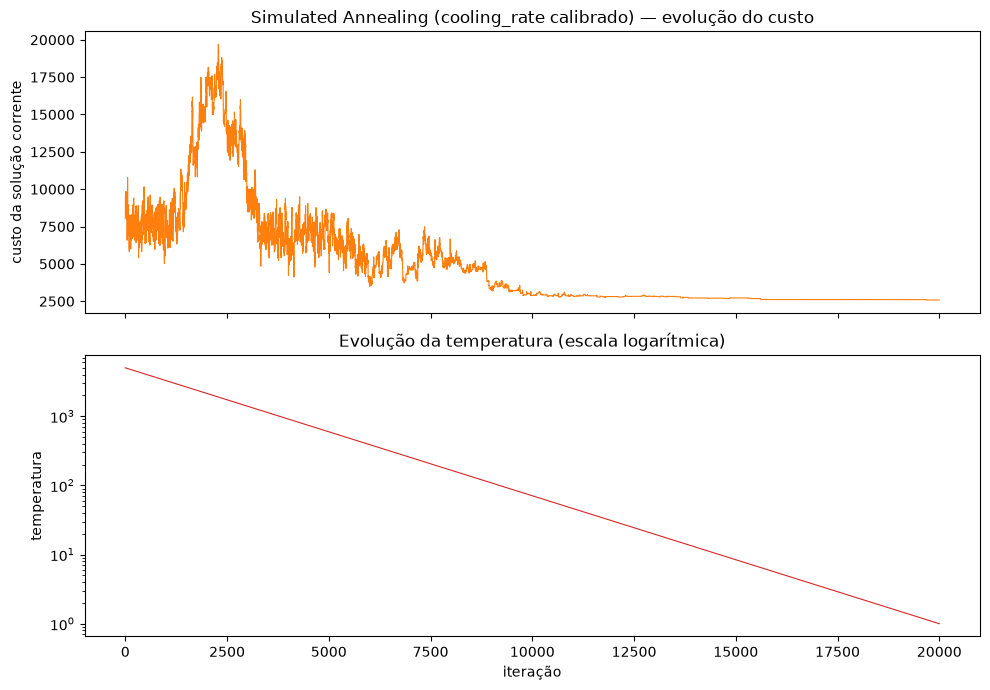

In [10]:
sa_result = simulated_annealing(
    distance_matrix=distance_matrix,
    customers=CUSTOMERS,
    charging_stations=CHARGING_STATIONS,
    depot=DEPOT,
    battery_capacity=BATTERY_CAPACITY,
    max_iterations=SA_MAX_ITERATIONS,
    rng=random.Random(HC_SEED),
    initial_temperature=INITIAL_TEMPERATURE,
    cooling_rate=NEW_COOLING_RATE,
)

print(f"Melhor custo encontrado: {sa_result.best_cost:.1f}")
print(f"Rota é viável: {is_feasible_route(sa_result.best_route, distance_matrix, BATTERY_CAPACITY) is True}")
print(f"Primeira iteração viável: {sa_result.first_feasible_iteration}")
print(f"Pioras aceitas após a primeira viabilidade: {sa_result.accepted_worsening_moves_after_feasibility}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot(sa_result.cost_history, color="tab:orange", linewidth=0.8)
ax1.set_ylabel("custo da solução corrente")
ax1.set_title("Simulated Annealing (cooling_rate calibrado) — evolução do custo")

ax2.plot(sa_result.temperature_history, color="tab:red", linewidth=0.8)
ax2.set_ylabel("temperatura")
ax2.set_xlabel("iteração")
ax2.set_yscale("log")
ax2.set_title("Evolução da temperatura (escala logarítmica)")

plt.tight_layout()
plt.show()


## Seção 6 — Variante aprimorada (Simulated Annealing com reaquecimento)


Linhas carregadas do CSV oficial: 90

Taxa de viabilidade por algoritmo (a partir do CSV):
algorithm
hill_climbing_fixed_budget                 0.967
simulated_annealing_reheating_calibrado    1.000
simulated_annealing_v2                     1.000
Name: is_feasible, dtype: float64



Melhor custo encontrado (seed=2026): 2912.0
Rota é viável: True
Eventos de reaquecimento nesta execução: 13
(confere com o CSV oficial: best_cost=2912.0)


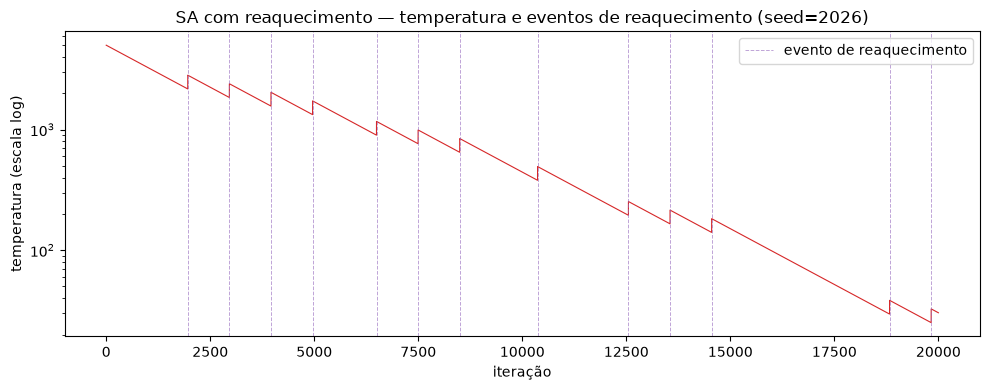

In [11]:
three_way_df = pd.read_csv(RESULTS_DIR / "comparacao_tres_vias_v2_reaquecimento_calibrado.csv")

print("Linhas carregadas do CSV oficial:", len(three_way_df))
print()
print("Taxa de viabilidade por algoritmo (a partir do CSV):")
print(three_way_df.groupby("algorithm")["is_feasible"].mean().round(3))

# --- Visualização da curva de temperatura e dos eventos de reaquecimento ---
# O CSV guarda apenas o NÚMERO de eventos de reaquecimento por execução
# (coluna `reheating_events_count`), não a lista de iterações em que cada
# evento ocorreu — informação necessária para marcar os eventos no gráfico.
# Por isso, reproduzimos ao vivo UMA execução (mesma seed e mesmos
# parâmetros calibrados usados no experimento oficial) só para essa
# visualização.
REHEAT_STAGNATION_LIMIT = 1000
REHEAT_FACTOR = 1.3

sa_reheating_result = simulated_annealing_with_reheating(
    distance_matrix=distance_matrix,
    customers=CUSTOMERS,
    charging_stations=CHARGING_STATIONS,
    depot=DEPOT,
    battery_capacity=BATTERY_CAPACITY,
    max_iterations=SA_MAX_ITERATIONS,
    rng=random.Random(HC_SEED),
    initial_temperature=INITIAL_TEMPERATURE,
    cooling_rate=NEW_COOLING_RATE,
    stagnation_limit=REHEAT_STAGNATION_LIMIT,
    reheat_factor=REHEAT_FACTOR,
)

print()
print(f"Melhor custo encontrado (seed={HC_SEED}): {sa_reheating_result.best_cost:.1f}")
print(f"Rota é viável: {is_feasible_route(sa_reheating_result.best_route, distance_matrix, BATTERY_CAPACITY) is True}")
print(f"Eventos de reaquecimento nesta execução: {len(sa_reheating_result.reheating_events)}")

# Checagem de consistência (não uma nova fonte de conclusão): a execução ao
# vivo, com a mesma seed e os mesmos parâmetros do experimento oficial, deve
# reproduzir exatamente a linha correspondente do CSV.
csv_row = three_way_df[
    (three_way_df["seed"] == HC_SEED)
    & (three_way_df["algorithm"] == "simulated_annealing_reheating_calibrado")
].iloc[0]
assert sa_reheating_result.best_cost == csv_row["best_cost"], "execução ao vivo diverge do CSV oficial"
print(f"(confere com o CSV oficial: best_cost={csv_row['best_cost']})")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sa_reheating_result.temperature_history, color="tab:red", linewidth=0.8)
for i, event_iteration in enumerate(sa_reheating_result.reheating_events):
    ax.axvline(
        event_iteration,
        color="tab:purple",
        linestyle="--",
        linewidth=0.7,
        alpha=0.6,
        label="evento de reaquecimento" if i == 0 else None,
    )
ax.set_yscale("log")
ax.set_xlabel("iteração")
ax.set_ylabel("temperatura (escala log)")
ax.set_title(f"SA com reaquecimento — temperatura e eventos de reaquecimento (seed={HC_SEED})")
ax.legend()
plt.tight_layout()
plt.show()


### O mecanismo de reaquecimento, e a jornada de calibração até aqui

O Simulated Annealing com reaquecimento estende o SA puro (Seção 5) com um
mecanismo simples: um contador acompanha há quantas iterações
**consecutivas** a melhor solução **global** não melhora. Quando esse
contador atinge `stagnation_limit`, a temperatura corrente é multiplicada
por `reheat_factor` (um "empurrão" de volta para cima) e o contador é
zerado — permitindo à busca voltar a aceitar vizinhos piores com mais
liberdade, mesmo depois de o resfriamento geométrico já ter esfriado
bastante. A ideia é dar à busca uma segunda (ou terceira, ou quarta) chance
de escapar de um ótimo local, sem reiniciar do zero como o Hill Climbing
faz.

A calibração desse mecanismo não foi direta — e o processo em si é um
resultado que vale registrar, porque ilustra bem como parâmetros de uma
variante podem depender de escolhas de design que, à primeira vista,
parecem independentes:

1. **Com o schedule de resfriamento original** (`cooling_rate=0.995`
   fixo), o reaquecimento (`stagnation_limit=500`, `reheat_factor=3.0` —
   valores exploratórios iniciais) parecia **inerte**: a temperatura já
   havia caído para frações de 1 bem antes de qualquer estagnação de 500
   iterações disparar um reaquecimento (o schedule original esgota o
   resfriamento em ~8,5% do orçamento de 20.000 iterações — Seção 5).
   Triplicar uma temperatura já próxima de zero continua próxima de zero;
   o reaquecimento nunca tinha chance de fazer diferença prática.
2. **Ao corrigir o schedule** para consumir o orçamento inteiro
   (`sa_utils.compute_cooling_rate`, Seção 5), a mesma combinação de
   reaquecimento deixou de ser inofensiva e passou a **quebrar o
   algoritmo**: com o schedule novo, a temperatura ainda está na casa dos
   milhares quando a primeira estagnação de 500 iterações ocorre — e
   triplicar uma temperatura já alta faz a probabilidade de aceitar
   qualquer vizinho (mesmo muito pior) disparar para perto de 1,
   transformando a busca num passeio essencialmente aleatório. Resultado
   medido nesse cenário: apenas **1 em 30** execuções encontrou uma rota
   viável, com custo médio mais que dobrado frente ao SA puro sob o mesmo
   schedule.
3. **A recalibração** para `stagnation_limit=1000` (reaquece com menos
   frequência) e `reheat_factor=1.3` (um empurrão de 30%, não uma
   triplicação) — os valores usados na execução acima e no experimento
   oficial desta seção — recuperou o comportamento básico do algoritmo:
   **30 em 30** execuções voltaram a encontrar viabilidade. Mas, como a
   Seção 7 discute, isso não foi suficiente para superar o SA puro sob o
   mesmo schedule.

O ponto central deste episódio: **os parâmetros de uma variante (aqui,
`reheat_factor` e `stagnation_limit`) não podem ser avaliados
isoladamente** — eles estão implicitamente acoplados a outras escolhas de
design do algoritmo base (aqui, o schedule de resfriamento do SA). Um
`reheat_factor` "razoável" sob um schedule pode ser inofensivo sob outro e
catastrófico sob um terceiro; recalibrar um parâmetro de uma variante exige
reconsiderar todo o restante do sistema em que ela está embutida, não só
o parâmetro isolado.


## Seção 7 — Comparação entre os três algoritmos

Esta seção usa **exclusivamente** os resultados salvos em
`resultados/comparacao_tres_vias_v2_reaquecimento_calibrado.csv` (já
carregado como `three_way_df` na Seção 6) para qualquer conclusão — gerado
por `run_three_way_comparison` com `n_runs=30`, mesmas seeds pareadas entre
os três algoritmos, mesmo `total_evaluations=20000`, cooling_rate calibrado
do SA (Seção 5) aplicado também ao SA-reaquecido, e o reaquecimento já na
configuração recalibrada (Seção 6). Os CSVs de rodadas anteriores (schedule
de resfriamento original, ou reaquecimento com os parâmetros exploratórios
iniciais) não são usados para nenhuma métrica final aqui — servem apenas de
registro histórico do processo de calibração, já discutido nas Seções 5 e
6.


In [12]:
ALGORITHMS_LABELS = {
    "hill_climbing_fixed_budget": "Hill Climbing (orçamento fixo)",
    "simulated_annealing_v2": "Simulated Annealing (schedule calibrado)",
    "simulated_annealing_reheating_calibrado": "SA com reaquecimento (calibrado)",
}

comparison_rows = []
for algo_key, algo_label in ALGORITHMS_LABELS.items():
    subset = three_way_df[three_way_df["algorithm"] == algo_key]
    costs = subset["best_cost"]
    feasible_iters = subset.loc[subset["first_feasible_iteration"].notna(), "first_feasible_iteration"]
    comparison_rows.append({
        "algoritmo": algo_label,
        "taxa de viabilidade": f"{int(subset['is_feasible'].sum())}/{len(subset)}",
        "custo mínimo": costs.min(),
        "custo máximo": costs.max(),
        "custo médio": costs.mean(),
        "custo mediano": costs.median(),
        "desvio padrão": costs.std(ddof=0),
        "mediana iteração até 1ª viável": feasible_iters.median() if len(feasible_iters) else None,
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("algoritmo").round(1)
comparison_df


,taxa de viabilidade,custo mínimo,custo máximo,custo médio,custo mediano,desvio padrão,mediana iteração até 1ª viável
algoritmo,,,,,,,
Hill Climbing (orçamento fixo),29/30,2453.0,3446.0,2750.1,2680.0,215.3,226.0
Simulated Annealing (schedule calibrado),30/30,2450.0,2675.0,2536.3,2530.0,51.9,1670.0
SA com reaquecimento (calibrado),30/30,2453.0,2923.0,2596.6,2556.0,125.7,1883.5


In [13]:
from itertools import combinations

algo_keys = list(ALGORITHMS_LABELS.keys())
wide_df = three_way_df.pivot(index="seed", columns="algorithm", values="best_cost")

print("Wilcoxon signed-rank pareado (custo final, n=30 pares cada):\n")
for algo_a, algo_b in combinations(algo_keys, 2):
    statistic, p_value = wilcoxon(wide_df[algo_a], wide_df[algo_b])
    label_a, label_b = ALGORITHMS_LABELS[algo_a], ALGORITHMS_LABELS[algo_b]
    print(f"{label_a}  vs  {label_b}")
    print(f"  statistic={statistic:.4f}   p-value={p_value:.6f}\n")


Wilcoxon signed-rank pareado (custo final, n=30 pares cada):

Hill Climbing (orçamento fixo)  vs  Simulated Annealing (schedule calibrado)
  statistic=36.5000   p-value=0.000055

Hill Climbing (orçamento fixo)  vs  SA com reaquecimento (calibrado)
  statistic=63.0000   p-value=0.000489

Simulated Annealing (schedule calibrado)  vs  SA com reaquecimento (calibrado)
  statistic=125.5000   p-value=0.027741



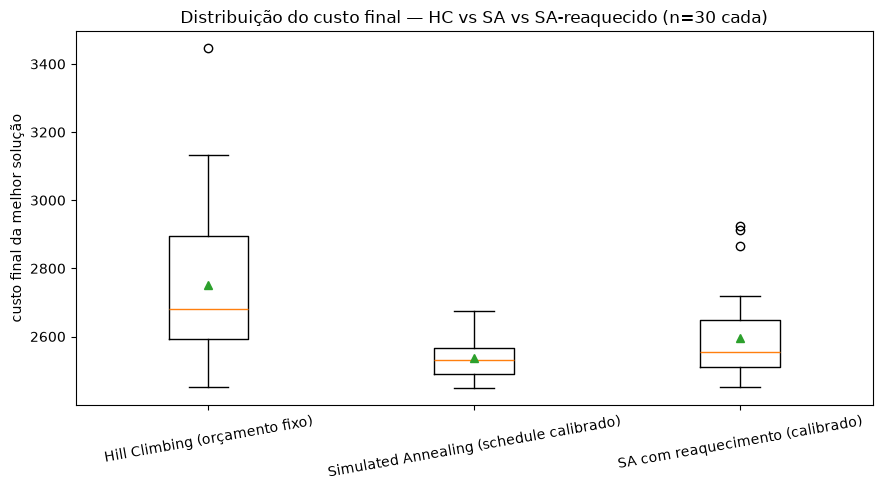

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
data_for_boxplot = [wide_df[algo].values for algo in algo_keys]
ax.boxplot(data_for_boxplot, showmeans=True)
ax.set_xticklabels([ALGORITHMS_LABELS[a] for a in algo_keys], rotation=10)
ax.set_ylabel("custo final da melhor solução")
ax.set_title("Distribuição do custo final — HC vs SA vs SA-reaquecido (n=30 cada)")
plt.tight_layout()
plt.show()


### Discussão

Os três testes de Wilcoxon pareados (célula acima) traçam um quadro
consistente:

- **SA puro supera o Hill Climbing** (p=0,000055) — a diferença mais forte
  das três, esperada dado que o SA usa o orçamento inteiro para explorar
  probabilisticamente (Seção 5), enquanto o HC, sob o mesmo orçamento,
  encerra na primeira estagnação de uma caminhada única e contínua.
- **SA com reaquecimento também supera o Hill Climbing** (p=0,000489) —
  mais fraco que o par anterior, mas ainda claramente significativo.
- **SA puro supera o SA com reaquecimento** (p=0,027741) — ou seja, a
  variante "aprimorada" **não** trouxe ganho sobre o algoritmo do qual
  derivou, embora continue sendo melhor que o Hill Climbing.

Vale qualificar esse terceiro resultado: p=0,027741 é estatisticamente
válido (abaixo do limiar convencional de 0,05), mas é uma significância
**modesta**, se comparada à ordem de grandeza dos outros dois p-valores
(0,000055 e 0,000489). O tamanho de efeito também é visivelmente menor — a
diferença de custo médio entre SA puro e SA-reaquecido (tabela comparativa
acima) é bem menor que a diferença de qualquer um deles frente ao HC. Não é
um resultado a ignorar, mas também não é um resultado tão robusto quanto os
outros dois.

**Por que o reaquecimento não ajudou aqui?** Uma hipótese razoável,
específica desta instância: o GR17 adaptado é um problema pequeno (17
nós). Com um schedule de resfriamento geométrico já bem calibrado para usar
o orçamento inteiro (Seção 5), o SA puro já dispõe de bastante tempo de
exploração probabilística mesmo sem nenhuma perturbação extra — o
reaquecimento foi originalmente motivado pela suspeita de que a busca
"esfriava cedo demais e ficava presa" (Seção 6), mas essa suspeita já foi
resolvida na origem, pelo próprio schedule corrigido. Em instâncias
maiores, com espaços de busca mais irregulares e mais suscetíveis a ótimos
locais persistentes mesmo sob um schedule bem calibrado, o reaquecimento
poderia ter um papel mais claramente positivo — mas não há evidência disso
para o GR17 nesta configuração.


## Seção 8 — Limitações e possibilidades de melhoria

Algumas limitações já identificadas e documentadas ao longo do
desenvolvimento deste módulo:

- **Mapeamento manual de estações de recarga sobre um TSP originalmente
  sem essa estrutura.** O GR17 é um TSP puro; os papéis de depósito,
  estações e clientes (Seção 1) foram atribuídos manualmente pela equipe
  aos nós existentes, sem nenhuma cidade adicionada, removida ou
  reposicionada. Isso significa que a topologia de estações não reflete um
  cenário real de planejamento de infraestrutura de recarga — foi
  escolhida para distribuir as estações ao longo do tour ótimo de
  referência (evitando concentração em um único trecho), mas é uma
  escolha de conveniência, não um dado observado.
- **Modelo de bateria simplificado.** A recarga é sempre **total** ao
  passar por um depósito ou estação (`RECHARGE_MODE="full"`), e o consumo
  de bateria é **1:1** com a distância percorrida
  (`CONSUMPTION_RATE=1.0`), sem fatores físicos como velocidade, peso da
  carga, topografia ou eficiência do motor. Este é um modelo adequado para
  demonstrar o efeito de uma restrição de autonomia sobre a busca, mas
  está longe de um modelo de bateria realista.
- **Tamanho amostral de n=30** para as execuções usadas nos testes
  estatísticos (Seção 7). Trinta execuções pareadas por seed é suficiente
  para aplicar o teste de Wilcoxon com razoável poder estatístico, mas é
  uma amostra pequena frente à variabilidade inerente de heurísticas
  estocásticas — resultados com significância limítrofe devem ser
  interpretados com cautela.
- **Dependência do estado inicial em casos de cauda longa.** Duas seeds
  específicas (2037 no Hill Climbing, 2055 no Simulated Annealing) não
  encontraram nenhuma solução viável dentro do orçamento oficial de 20.000
  avaliações — mas ambas convergem quando o orçamento é multiplicado por 5
  (100.000 avaliações): o HC na iteração 44.026, o SA (schedule calibrado,
  recalibrado para o novo orçamento) na iteração 1.552. Isso mostra que não
  são "becos sem saída" do espaço de busca, mas evidencia uma dependência
  real do estado inicial — para certas rotas de partida, o caminho até a
  primeira viabilidade pode ser bem mais longo que a mediana observada nas
  demais execuções (ver Seção 7, coluna "mediana iteração até 1ª viável").
- **Sensibilidade a hiperparâmetros como limitação de todo o processo
  experimental, não só do reaquecimento.** O episódio de calibração
  descrito nas Seções 5 e 6 — `cooling_rate` fixo mascarando o potencial do
  SA por esgotar o resfriamento em ~8,5% do orçamento; `reheat_factor=3.0`
  inofensivo sob esse schedule, mas catastrófico (1/30 execuções viáveis)
  sob o schedule corrigido; a recalibração subsequente para
  `reheat_factor=1.3`/`stagnation_limit=1000` — evidencia que os
  resultados de heurísticas de Busca Local são sensíveis a escolhas de
  hiperparâmetros que interagem entre si de formas nem sempre óbvias a
  priori. Isso não invalida as conclusões (cada rodada foi validada
  empiricamente, não apenas assumida), mas é uma limitação metodológica
  geral: outra combinação de parâmetros, não testada aqui, poderia mudar
  os resultados relativos entre os três algoritmos.


## Seção 9 — Referências

- **TSPLIB / GR17**: Groetschel, M. *GR17 — 17-city problem*, TSPLIB
  (Universität Heidelberg). Dataset de origem, adaptado para EVRP neste
  módulo (Seção 1).
- Schneider, M.; Stenger, A.; Goeke, D. (2014). *"The Electric
  Vehicle-Routing Problem with Time Windows and Recharging Stations."*
  Transportation Science, 48(4). Dataset EVRP avaliado e descartado (Seção
  1) por incluir uma dimensão de complexidade (janelas de tempo) além do
  escopo do módulo.
- Gialos, A.; Zeimpekis, V. (2023). *EC-TSP dataset.* Mendeley Data.
  Dataset EVRP avaliado e descartado (Seção 1) por exigir um trabalho de
  *parsing*/limpeza desproporcional ao tempo disponível.
- **[CONFIRMAR REFERÊNCIA]** Os demais métodos usados neste módulo (Hill
  Climbing com reinício aleatório, Simulated Annealing, resfriamento
  geométrico) seguem a literatura clássica de Inteligência Artificial. A
  referência padrão de curso mais provável é *Russell, S.; Norvig, P.
  Artificial Intelligence: A Modern Approach* — a equipe deve confirmar
  (ou substituir por) a bibliografia efetivamente usada em sala antes da
  entrega final.
